# 29 — Firewall Ensemble Performance Evaluation

**Purpose:** Comprehensive evaluation of the deployed VPN detection firewall ensemble.

Covers:
1. Per-model family comparison (XGBoost vs LightGBM vs CatBoost)
2. Ensemble vs individual models
3. Calibration comparison (Raw vs Isotonic vs Platt)
4. Session aggregation strategies (p90 vs weighted-top5 vs mean)
5. Deployment modes (STRICT vs BALANCED vs RESEARCH)
6. Per-dataset breakdown (ISCX vs VNAT)
7. Threshold selection visualization
8. ROC & PR curves
9. Score distributions
10. Final deployment summary table

In [1]:
%matplotlib inline

import sys, os
# Ensure project root is on path (for jupyter kernels)
_root = os.path.abspath(os.path.join(os.getcwd(), '..')) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if _root not in sys.path:
    sys.path.insert(0, _root)
os.chdir(_root)

import json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss

from src.utils.paths import load_paths
from src.eval.metrics import threshold_at_fpr, confusion_at_threshold

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 6)

COLORS = {
    'xgb':'#2196F3','lgbm':'#4CAF50','cat':'#FF9800',
    'ensemble_raw':'#9C27B0','ensemble_iso':'#E91E63',
    'ensemble_platt':'#795548','benign':'#43A047','vpn':'#E53935',
}

paths = load_paths()
ENSEMBLE_DIR = paths.artifacts_root / 'balanced_bagging_firewall_tuned_ensemble'
print('Ensemble dir:', ENSEMBLE_DIR)

Ensemble dir: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble


## 1. Load Predictions & Metrics

In [2]:
df = pd.read_csv(ENSEMBLE_DIR / 'predictions.csv')
print(f'Total flows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
print(f'Splits: {df["split"].value_counts().to_dict()}')
print(f'Datasets: {df["dataset"].value_counts().to_dict()}')
print()

train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()

print(f'Train: {len(train_df):,} flows ({train_df["label"].sum()} VPN)')
print(f'Val:   {len(val_df):,} flows ({val_df["label"].sum()} VPN)')
print(f'Test:  {len(test_df):,} flows ({test_df["label"].sum()} VPN)')

with open(ENSEMBLE_DIR / 'metrics.json') as f:
    saved_metrics = json.load(f)
print(f'\nSaved metric keys: {list(saved_metrics.keys())}')

Total flows: 19,908
Columns: ['capture_id', 'dataset', 'label', 'flow_id', 'p_xgb_raw', 'p_lgbm_raw', 'p_cat_raw', 'prob_raw', 'prob_iso', 'prob_platt', 'prob', 'split']
Splits: {'train': 16138, 'val': 1926, 'test': 1844}
Datasets: {'iscx': 11801, 'vnat': 8107}

Train: 16,138 flows (2378 VPN)
Val:   1,926 flows (688 VPN)
Test:  1,844 flows (251 VPN)

Saved metric keys: ['ensemble_weights', 'raw', 'isotonic', 'platt']


## 2. Per-Model Family Comparison

Comparing the three base learners: **XGBoost**, **LightGBM**, and **CatBoost** at flow level.

In [3]:
family_cols = {
    'XGBoost':  'p_xgb_raw',
    'LightGBM': 'p_lgbm_raw',
    'CatBoost':  'p_cat_raw',
    'Ensemble (raw)': 'prob_raw',
    'Ensemble (isotonic)': 'prob_iso',
    'Ensemble (platt)': 'prob_platt',
}

results = []
for split_name, split_df in [('val', val_df), ('test', test_df)]:
    y = split_df['label'].values
    for name, col in family_cols.items():
        p = split_df[col].values
        results.append({
            'Model': name, 'Split': split_name,
            'ROC-AUC': roc_auc_score(y, p),
            'PR-AUC': average_precision_score(y, p),
        })

auc_df = pd.DataFrame(results)
print('Flow-Level AUC Comparison:')
print(auc_df.pivot(index='Model', columns='Split', values='ROC-AUC').round(4).to_string())
print()
print('Flow-Level PR-AUC Comparison:')
print(auc_df.pivot(index='Model', columns='Split', values='PR-AUC').round(4).to_string())

Flow-Level AUC Comparison:
Split                  test     val
Model                              
CatBoost             0.9492  0.9824
Ensemble (isotonic)  0.9461  0.9846
Ensemble (platt)     0.9443  0.9817
Ensemble (raw)       0.9443  0.9817
LightGBM             0.9410  0.9774
XGBoost              0.9427  0.9796

Flow-Level PR-AUC Comparison:
Split                  test     val
Model                              
CatBoost             0.8804  0.9775
Ensemble (isotonic)  0.8496  0.9754
Ensemble (platt)     0.8613  0.9773
Ensemble (raw)       0.8613  0.9773
LightGBM             0.8490  0.9741
XGBoost              0.8516  0.9756


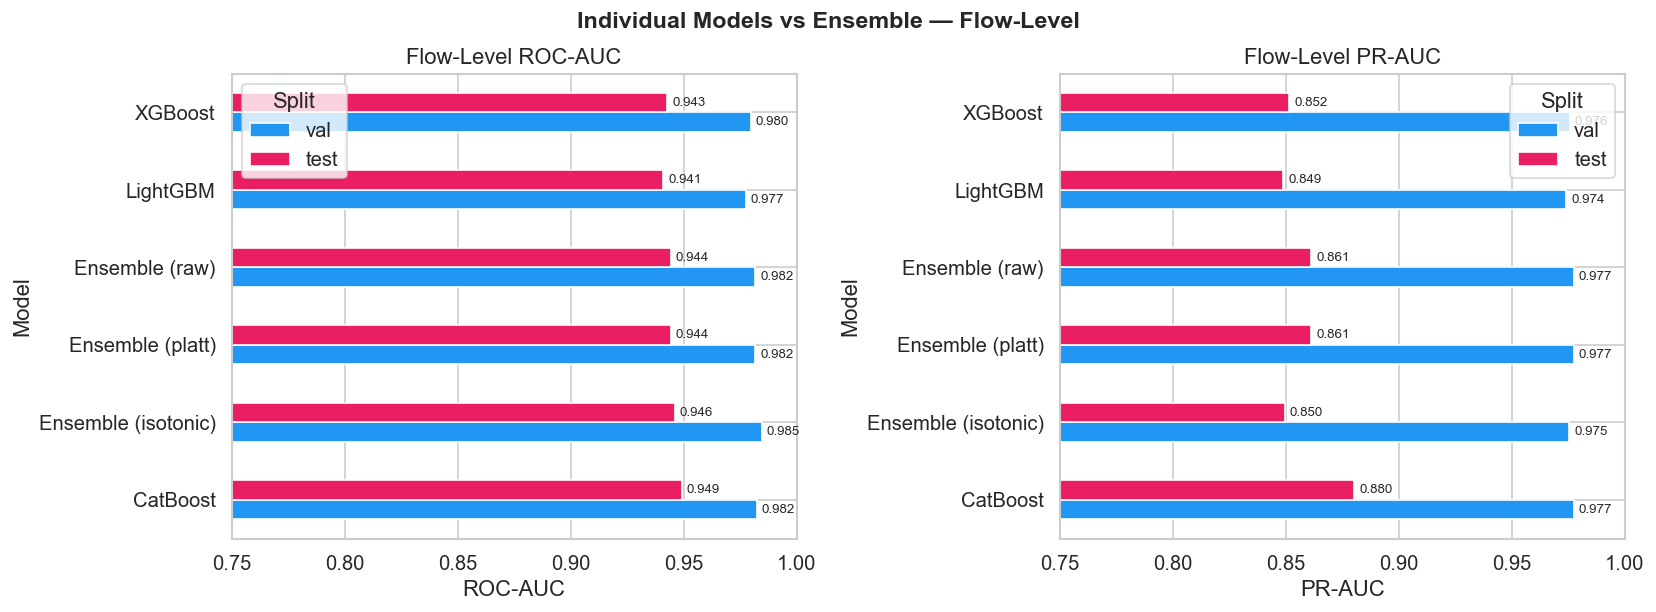

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['ROC-AUC', 'PR-AUC']):
    pivot = auc_df.pivot(index='Model', columns='Split', values=metric)[['val', 'test']]
    pivot.plot(kind='barh', ax=ax, color=['#2196F3', '#E91E63'])
    ax.set_title(f'Flow-Level {metric}')
    ax.set_xlabel(metric)
    ax.set_xlim(0.75, 1.0)
    ax.legend(title='Split')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=8, padding=3)
plt.tight_layout()
plt.suptitle('Individual Models vs Ensemble — Flow-Level', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 3. ROC & Precision-Recall Curves (Test Set, Flow-Level)

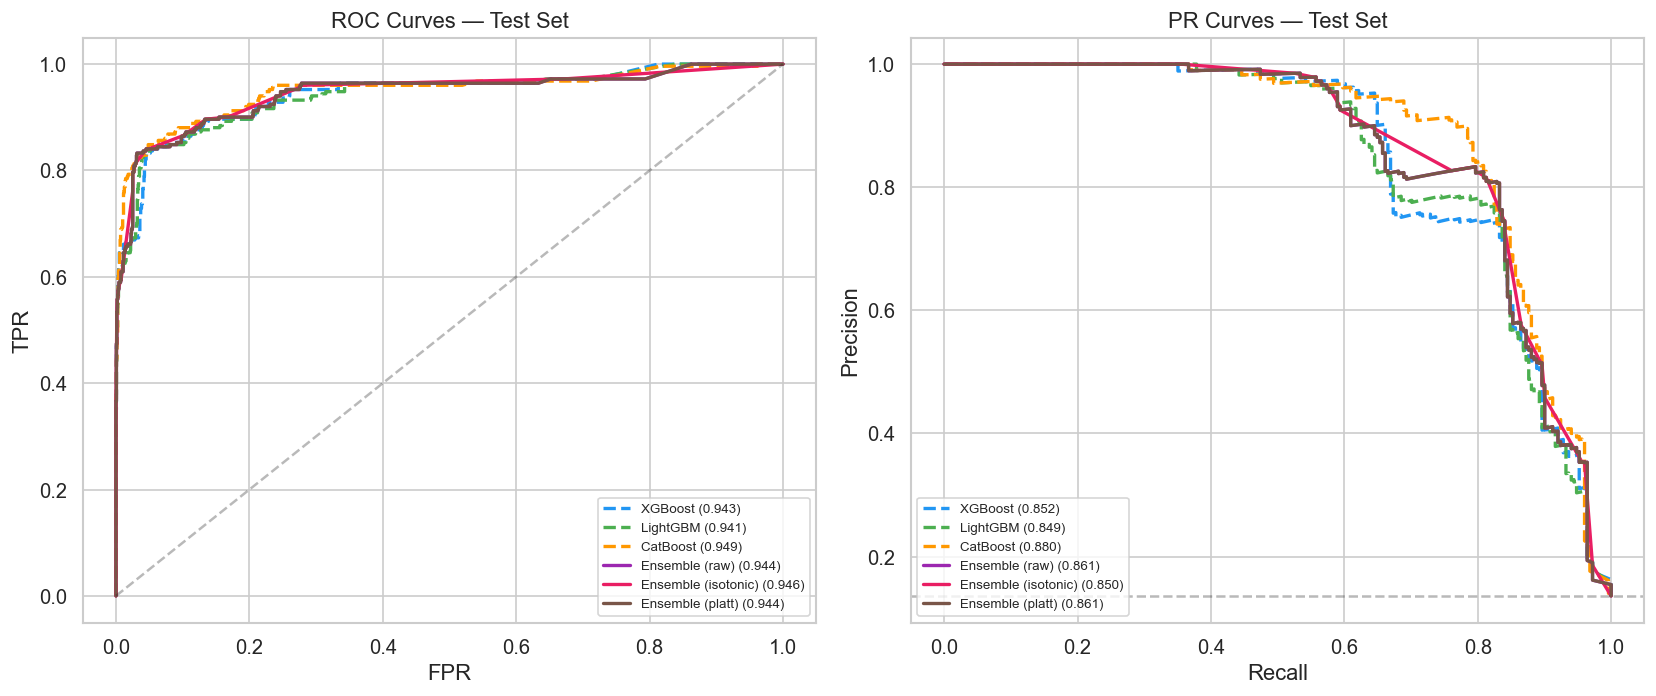

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
y_test = test_df['label'].values

curve_defs = [
    ('XGBoost','p_xgb_raw',COLORS['xgb'],'--'),
    ('LightGBM','p_lgbm_raw',COLORS['lgbm'],'--'),
    ('CatBoost','p_cat_raw',COLORS['cat'],'--'),
    ('Ensemble (raw)','prob_raw',COLORS['ensemble_raw'],'-'),
    ('Ensemble (isotonic)','prob_iso',COLORS['ensemble_iso'],'-'),
    ('Ensemble (platt)','prob_platt',COLORS['ensemble_platt'],'-'),
]

ax = axes[0]
for name, col, color, ls in curve_defs:
    fpr, tpr, _ = roc_curve(y_test, test_df[col].values)
    auc_val = roc_auc_score(y_test, test_df[col].values)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2, label=f'{name} ({auc_val:.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves — Test Set'); ax.legend(fontsize=8, loc='lower right')

ax = axes[1]
for name, col, color, ls in curve_defs:
    prec, rec, _ = precision_recall_curve(y_test, test_df[col].values)
    pr_auc = average_precision_score(y_test, test_df[col].values)
    ax.plot(rec, prec, color=color, linestyle=ls, linewidth=2, label=f'{name} ({pr_auc:.3f})')
ax.axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.3)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — Test Set'); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

### 3b. ROC — Low-FPR Zoom (Deployment Region)

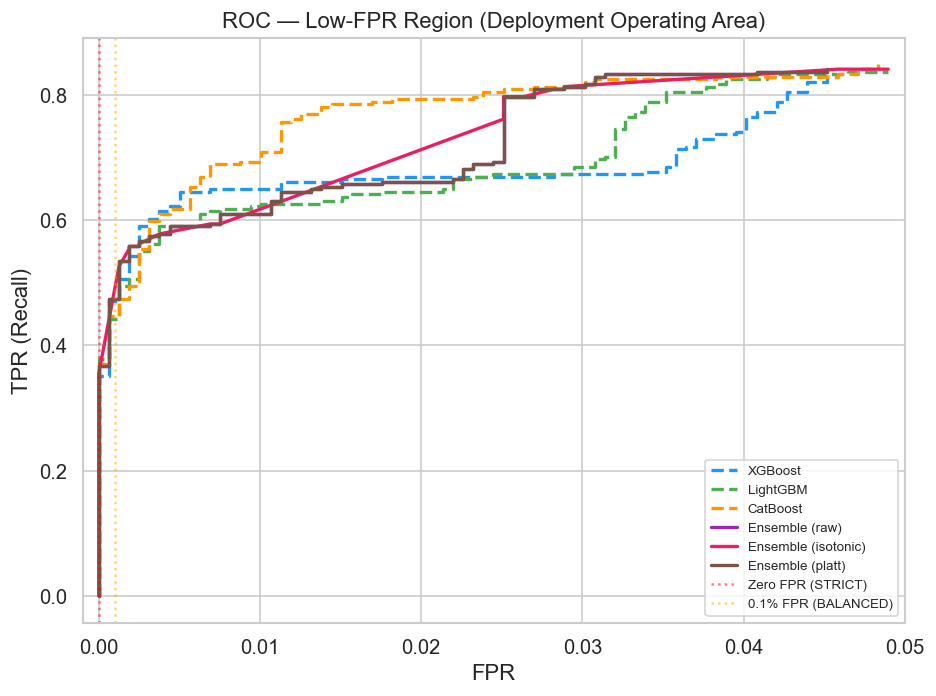

In [6]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, col, color, ls in curve_defs:
    fpr, tpr, _ = roc_curve(y_test, test_df[col].values)
    mask = fpr <= 0.05
    ax.plot(fpr[mask], tpr[mask], color=color, linestyle=ls, linewidth=2, label=name)
ax.axvline(x=0.0, color='red', linestyle=':', alpha=0.5, label='Zero FPR (STRICT)')
ax.axvline(x=0.001, color='orange', linestyle=':', alpha=0.5, label='0.1% FPR (BALANCED)')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR (Recall)')
ax.set_title('ROC — Low-FPR Region (Deployment Operating Area)')
ax.legend(fontsize=8); ax.set_xlim(-0.001, 0.05)
plt.tight_layout(); plt.show()

## 4. Calibration Comparison (Reliability Diagrams)

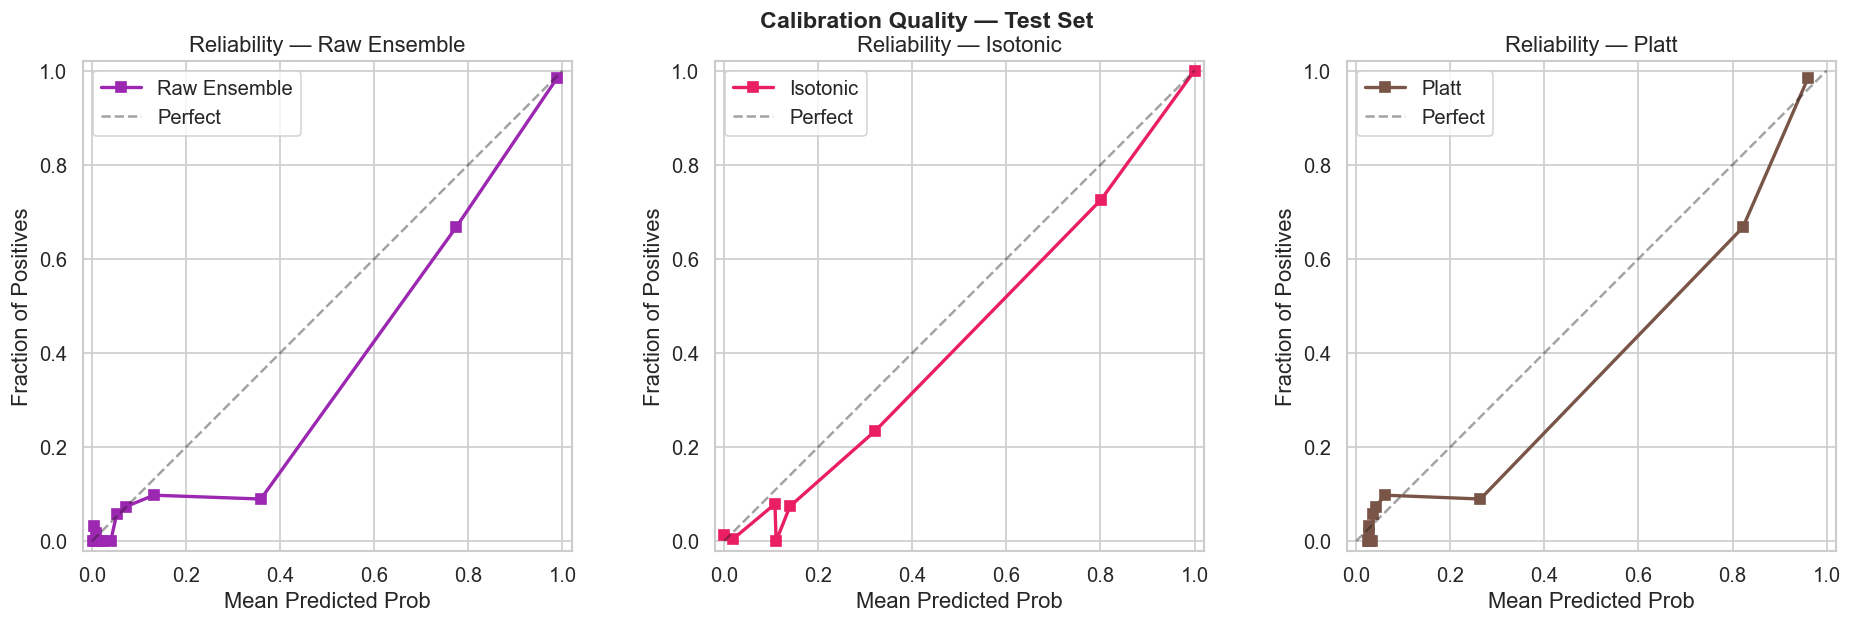

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
calib_methods = [
    ('Raw Ensemble','prob_raw',COLORS['ensemble_raw']),
    ('Isotonic','prob_iso',COLORS['ensemble_iso']),
    ('Platt','prob_platt',COLORS['ensemble_platt']),
]
for ax, (name, col, color) in zip(axes, calib_methods):
    prob_true, prob_pred = calibration_curve(y_test, test_df[col].values, n_bins=15, strategy='quantile')
    ax.plot(prob_pred, prob_true, 's-', color=color, linewidth=2, markersize=6, label=name)
    ax.plot([0,1],[0,1],'k--',alpha=0.4,label='Perfect')
    ax.set_xlabel('Mean Predicted Prob'); ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Reliability — {name}'); ax.legend()
    ax.set_xlim(-0.02,1.02); ax.set_ylim(-0.02,1.02); ax.set_aspect('equal')
plt.tight_layout()
plt.suptitle('Calibration Quality — Test Set', y=1.02, fontsize=14, fontweight='bold')
plt.show()

In [8]:
calib_results = []
for name, col, _ in calib_methods:
    p = test_df[col].values
    calib_results.append({
        'Method': name,
        'ROC-AUC': roc_auc_score(y_test, p),
        'PR-AUC': average_precision_score(y_test, p),
        'Brier Score': brier_score_loss(y_test, p),
        'Log Loss': log_loss(y_test, np.clip(p, 1e-12, 1-1e-12)),
    })
calib_table = pd.DataFrame(calib_results).set_index('Method')
print('Calibration Method Comparison (Test Set, Flow-Level):')
print(calib_table.round(4).to_string())

Calibration Method Comparison (Test Set, Flow-Level):
              ROC-AUC  PR-AUC  Brier Score  Log Loss
Method                                              
Raw Ensemble   0.9443  0.8613       0.0462    0.1687
Isotonic       0.9461  0.8496       0.0407    0.2367
Platt          0.9443  0.8613       0.0451    0.1712


## 5. Score Distributions (Benign vs VPN)

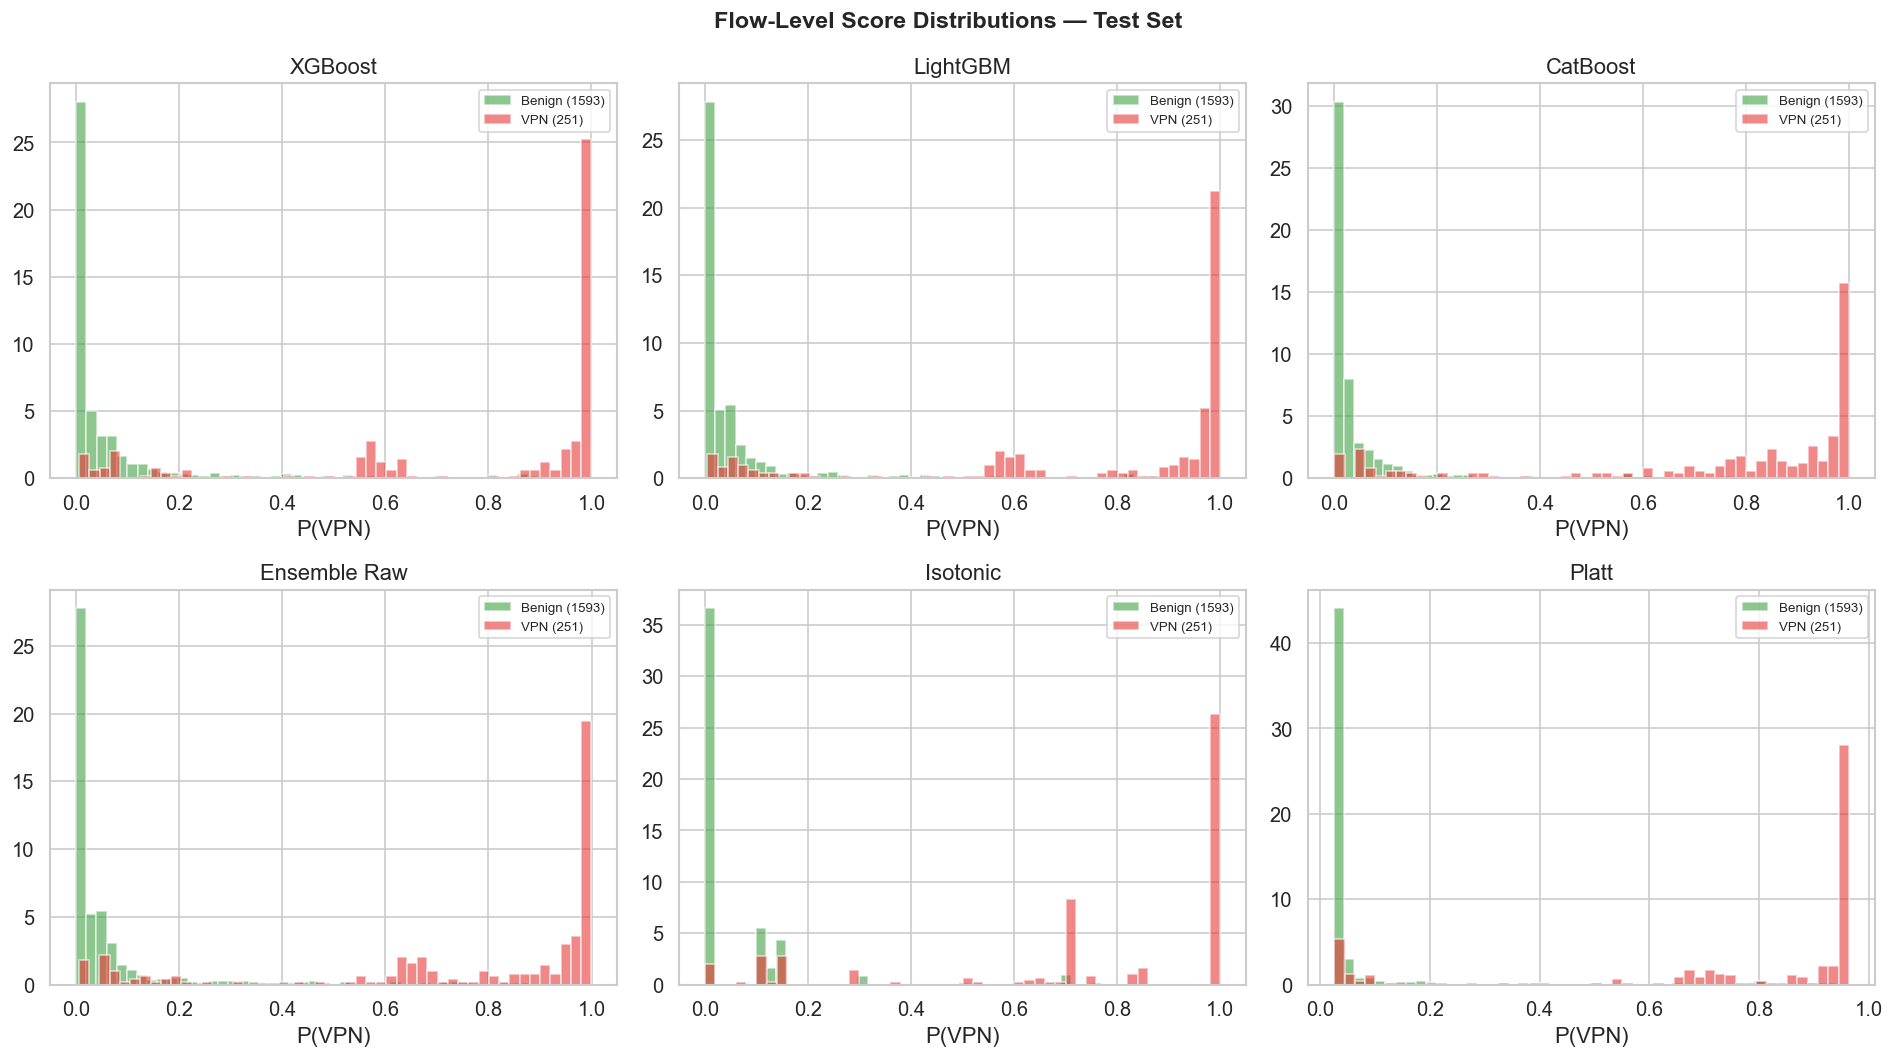

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
dist_cols = [
    ('XGBoost','p_xgb_raw'), ('LightGBM','p_lgbm_raw'), ('CatBoost','p_cat_raw'),
    ('Ensemble Raw','prob_raw'), ('Isotonic','prob_iso'), ('Platt','prob_platt'),
]
for ax, (name, col) in zip(axes.ravel(), dist_cols):
    b = test_df.loc[test_df['label']==0, col].values
    v = test_df.loc[test_df['label']==1, col].values
    ax.hist(b, bins=50, alpha=0.6, color=COLORS['benign'], label=f'Benign ({len(b)})', density=True)
    ax.hist(v, bins=50, alpha=0.6, color=COLORS['vpn'], label=f'VPN ({len(v)})', density=True)
    ax.set_title(name); ax.set_xlabel('P(VPN)'); ax.legend(fontsize=8)
plt.suptitle('Flow-Level Score Distributions — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Session-Level Aggregation Comparison

Comparing p90, weighted-top-5-mean, and mean aggregation at the session level.

In [10]:
def p90_agg(x):
    return np.percentile(x, 90)

def weighted_top5(x):
    vals = np.sort(x)[::-1][:5]
    w = np.array([0.40, 0.25, 0.15, 0.10, 0.10])[:len(vals)]
    w = w / w.sum()
    return float(np.sum(vals * w))

def mean_agg(x):
    return np.mean(x)

agg_rules = {'p90': p90_agg, 'weighted_top5_mean': weighted_top5, 'mean': mean_agg}
prob_cols_to_test = ['prob_iso', 'prob_raw', 'prob_platt']

session_results = []
for split_name, split_df in [('val', val_df), ('test', test_df)]:
    session_labels = split_df.groupby('capture_id')['label'].max()
    for prob_col in prob_cols_to_test:
        for agg_name, agg_fn in agg_rules.items():
            session_scores = split_df.groupby('capture_id')[prob_col].apply(lambda x: agg_fn(x.values))
            common = session_labels.index.intersection(session_scores.index)
            y = session_labels.loc[common].values
            s = session_scores.loc[common].values
            if len(np.unique(y)) < 2: continue
            benign_s = s[y == 0]; vpn_s = s[y == 1]
            block_thr = np.max(benign_s)
            session_results.append({
                'Split': split_name,
                'Calibration': prob_col.replace('prob_', ''),
                'Aggregation': agg_name,
                'Session AUC': roc_auc_score(y, s),
                'Session PR-AUC': average_precision_score(y, s),
                'Block Recall (FPR=0)': float(np.mean(vpn_s > block_thr)),
                'N Sessions': len(common),
            })

session_df_all = pd.DataFrame(session_results)
print('Session-Level Results (Test Set):')
test_sessions = session_df_all[session_df_all['Split'] == 'test'].copy()
print(test_sessions[['Calibration','Aggregation','Session AUC','Session PR-AUC','Block Recall (FPR=0)']]
      .sort_values('Block Recall (FPR=0)', ascending=False).round(4).to_string(index=False))

Session-Level Results (Test Set):
Calibration        Aggregation  Session AUC  Session PR-AUC  Block Recall (FPR=0)
        iso               mean       0.9980          0.9967                0.9412
      platt               mean       0.9980          0.9967                0.9412
        raw               mean       0.9980          0.9967                0.9412
      platt                p90       0.9922          0.9867                0.8235
        raw                p90       0.9922          0.9867                0.8235
        iso                p90       0.9902          0.9775                0.7647
        iso weighted_top5_mean       0.9686          0.9518                0.7059
        raw weighted_top5_mean       0.9706          0.9530                0.7059
      platt weighted_top5_mean       0.9745          0.9581                0.7059


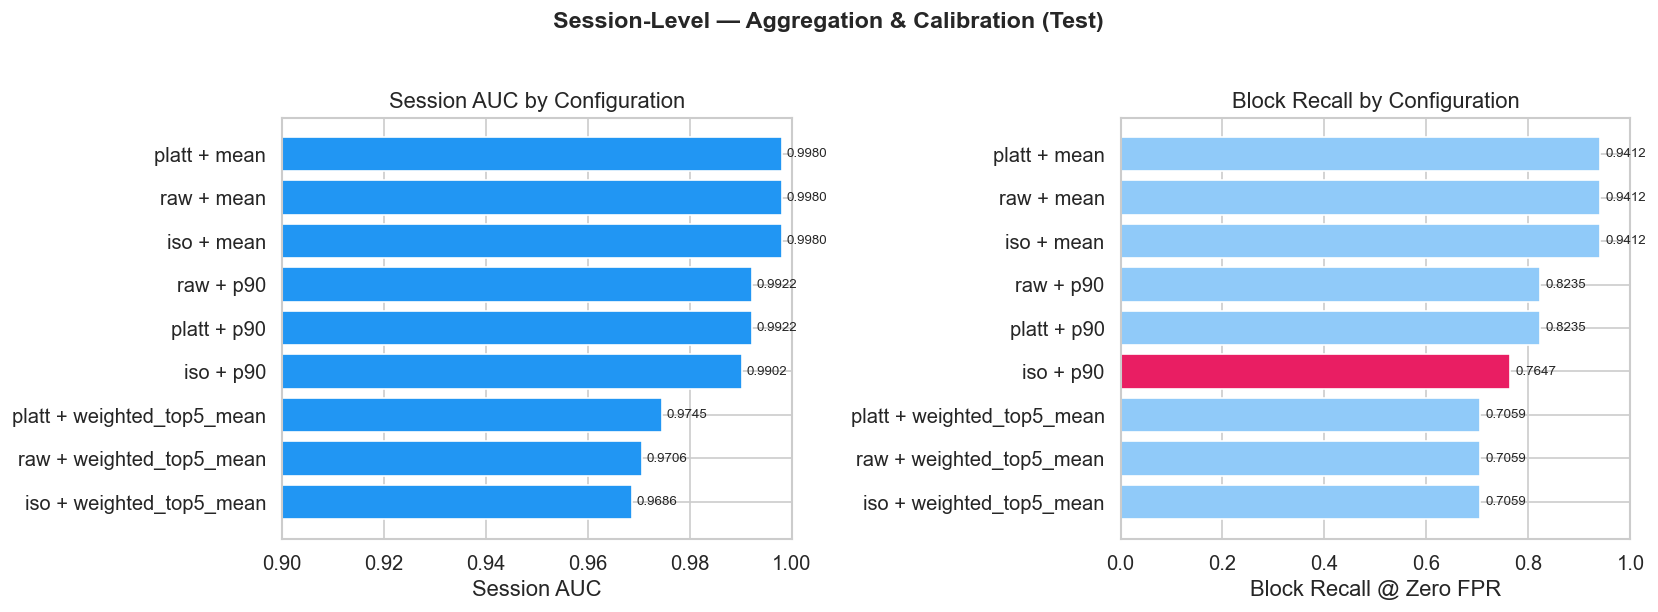

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
test_s = session_df_all[session_df_all['Split'] == 'test'].copy()
test_s['Config'] = test_s['Calibration'] + ' + ' + test_s['Aggregation']

ax = axes[0]
ts = test_s.sort_values('Session AUC', ascending=True)
ax.barh(ts['Config'], ts['Session AUC'], color='#2196F3', edgecolor='white')
ax.set_xlabel('Session AUC'); ax.set_title('Session AUC by Configuration')
ax.set_xlim(0.9, 1.0)
for i, v in enumerate(ts['Session AUC']): ax.text(v+0.001, i, f'{v:.4f}', va='center', fontsize=8)

ax = axes[1]
ts2 = test_s.sort_values('Block Recall (FPR=0)', ascending=True)
colors = ['#E91E63' if 'iso' in c and 'p90' in c else '#90CAF9' for c in ts2['Config']]
ax.barh(ts2['Config'], ts2['Block Recall (FPR=0)'], color=colors, edgecolor='white')
ax.set_xlabel('Block Recall @ Zero FPR'); ax.set_title('Block Recall by Configuration')
ax.set_xlim(0, 1.0)
for i, v in enumerate(ts2['Block Recall (FPR=0)']): ax.text(v+0.01, i, f'{v:.4f}', va='center', fontsize=8)

plt.suptitle('Session-Level — Aggregation & Calibration (Test)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Threshold Selection Visualization

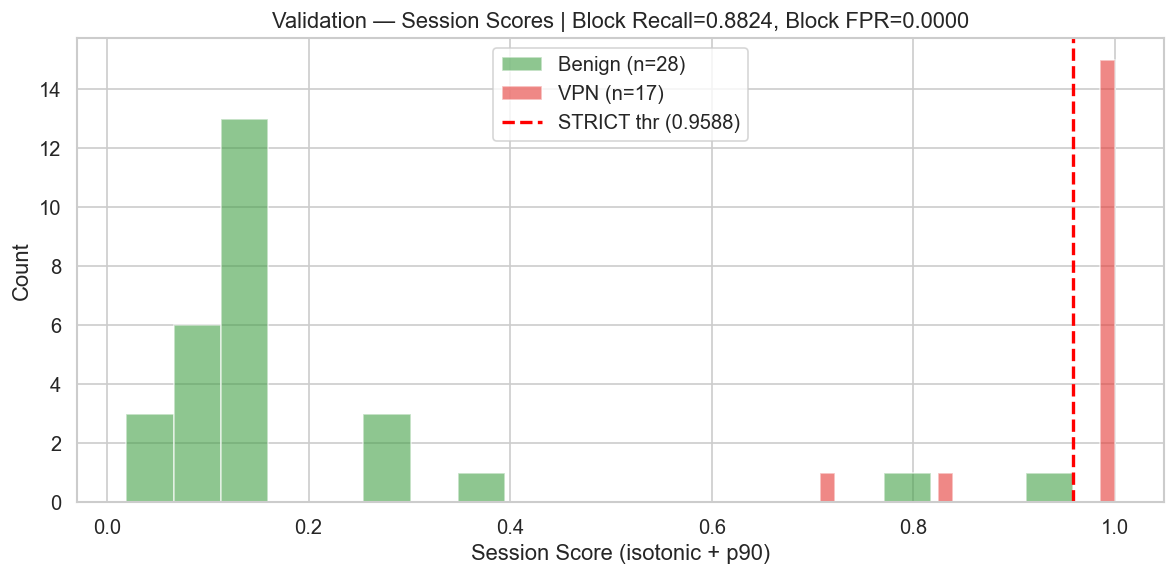

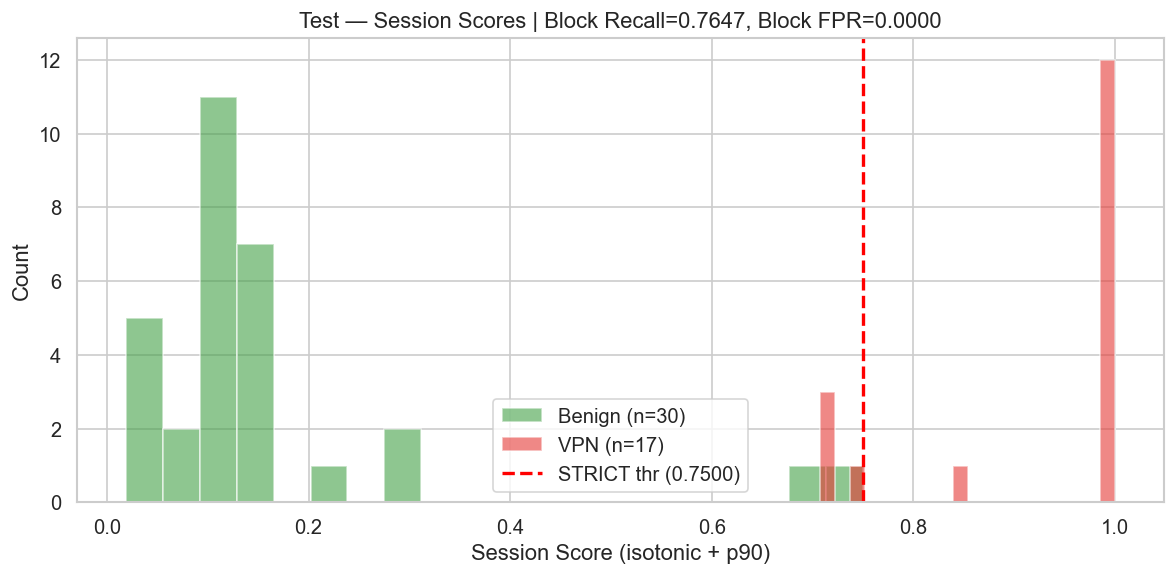

In [12]:
for split_name, split_df in [('Validation', val_df), ('Test', test_df)]:
    session_labels = split_df.groupby('capture_id')['label'].max()
    session_scores = split_df.groupby('capture_id')['prob_iso'].apply(lambda x: p90_agg(x.values))
    common = session_labels.index.intersection(session_scores.index)
    y = session_labels.loc[common].values
    s = session_scores.loc[common].values
    benign_s = s[y == 0]; vpn_s = s[y == 1]
    strict_thr = np.max(benign_s)
    block_recall = float(np.mean(vpn_s > strict_thr))

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(benign_s, bins=20, alpha=0.6, color=COLORS['benign'], label=f'Benign (n={len(benign_s)})', edgecolor='white')
    ax.hist(vpn_s, bins=20, alpha=0.6, color=COLORS['vpn'], label=f'VPN (n={len(vpn_s)})', edgecolor='white')
    ax.axvline(strict_thr, color='red', linewidth=2, linestyle='--', label=f'STRICT thr ({strict_thr:.4f})')
    ax.set_xlabel('Session Score (isotonic + p90)')
    ax.set_ylabel('Count')
    ax.set_title(f'{split_name} — Session Scores | Block Recall={block_recall:.4f}, Block FPR=0.0000')
    ax.legend()
    plt.tight_layout(); plt.show()

## 8. Deployment Mode Comparison (STRICT vs BALANCED vs RESEARCH)

In [13]:
from demo_firewall import FirewallBlocker, DeploymentMode

mode_metrics = {}
for mode in DeploymentMode:
    blocker = FirewallBlocker(mode=mode)
    blocker.load()
    if mode != DeploymentMode.RESEARCH:
        blocker.calibrate_from_validation()
    else:
        blocker._policy._block_threshold = 0.5
        blocker._policy._flag_threshold = 0.3
        blocker._policy._thresholds_calibrated = True
    m = blocker.evaluate_dataset()
    m['block_threshold'] = blocker._policy._block_threshold
    m['flag_threshold'] = blocker._policy._flag_threshold
    mode_metrics[mode.value] = m

mode_df = pd.DataFrame(mode_metrics).T
mode_df.index.name = 'Mode'
display_cols = ['session_roc_auc','session_pr_auc','block_recall','block_fpr',
                'block_precision','flagged_recall','flagged_fpr','block_threshold','flag_threshold']
print('Deployment Mode Comparison:')
print(mode_df[display_cols].round(4).to_string())

2026-03-30 14:11:23 | INFO | firewall.blocker | Loading firewall pipeline (mode=strict)...


2026-03-30 14:11:23 | INFO | firewall.predictor | Loaded isotonic calibrator (raw sklearn IsotonicRegression)


2026-03-30 14:11:23 | INFO | firewall.predictor | Ensemble loaded: 9 models across 3 families, calibration=isotonic


2026-03-30 14:11:23 | INFO | firewall.blocker | Firewall pipeline loaded successfully.


2026-03-30 14:11:23 | INFO | firewall.blocker | Loading validation predictions from C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble\predictions.csv


...

2026-03-30 14:11:24 | INFO | firewall.predictor | Loaded isotonic calibrator (raw sklearn IsotonicRegression)


2026-03-30 14:11:24 | INFO | firewall.predictor | Ensemble loaded: 9 models across 3 families, calibration=isotonic


2026-03-30 14:11:24 | INFO | firewall.blocker | Firewall pipeline loaded successfully.


Deployment Mode Comparison:

         session_roc_auc session_pr_auc block_recall block_fpr block_precision flagged_recall flagged_fpr block_threshold flag_threshold
Mode                                                                                                                                    
strict          0.990196       0.977503     0.705882       0.0             1.0            1.0    0.066667        0.958769       0.671138
balanced        0.968627       0.951804     0.705882  0.033333        0.923077            1.0    0.166667        0.875476       0.437738
research        0.998039       0.996732          0.0       0.0             0.0            0.0         0.0             0.5            0.3

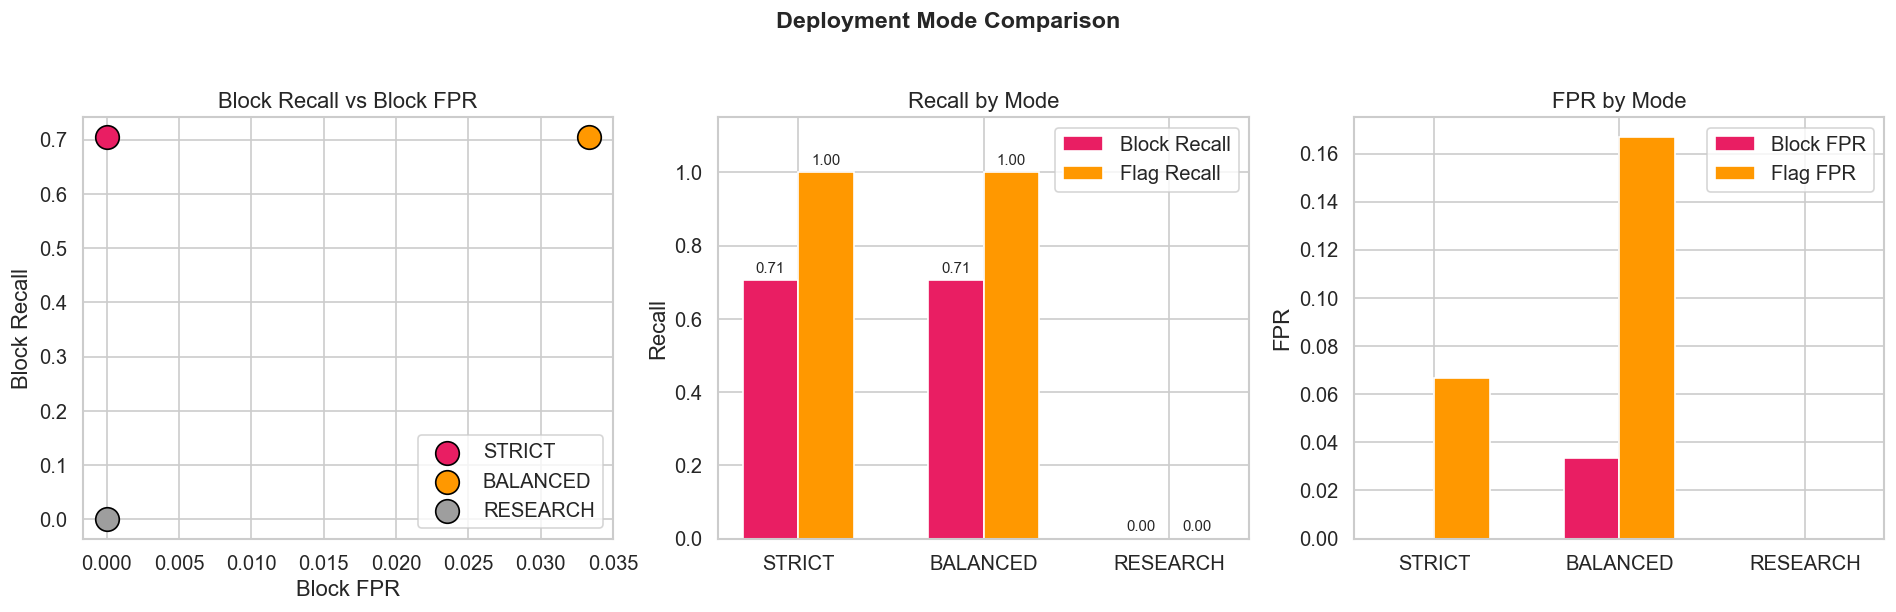

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
mode_names = ['strict', 'balanced', 'research']
mode_colors = ['#E91E63', '#FF9800', '#9E9E9E']
x = np.arange(len(mode_names))

ax = axes[0]
for mn, mc in zip(mode_names, mode_colors):
    m = mode_metrics[mn]
    ax.scatter(m['block_fpr'], m['block_recall'], s=200, c=mc, edgecolors='black', zorder=5, label=mn.upper())
ax.set_xlabel('Block FPR'); ax.set_ylabel('Block Recall')
ax.set_title('Block Recall vs Block FPR'); ax.legend()

ax = axes[1]
br = [mode_metrics[m].get('block_recall',0) for m in mode_names]
fr = [mode_metrics[m].get('flagged_recall',0) for m in mode_names]
ax.bar(x-0.15, br, 0.3, label='Block Recall', color='#E91E63')
ax.bar(x+0.15, fr, 0.3, label='Flag Recall', color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in mode_names])
ax.set_ylabel('Recall'); ax.set_title('Recall by Mode'); ax.legend(); ax.set_ylim(0,1.15)
for i,(b,f) in enumerate(zip(br,fr)):
    ax.text(i-0.15, b+0.02, f'{b:.2f}', ha='center', fontsize=9)
    ax.text(i+0.15, f+0.02, f'{f:.2f}', ha='center', fontsize=9)

ax = axes[2]
bf = [mode_metrics[m].get('block_fpr',0) for m in mode_names]
ff = [mode_metrics[m].get('flagged_fpr',0) for m in mode_names]
ax.bar(x-0.15, bf, 0.3, label='Block FPR', color='#E91E63')
ax.bar(x+0.15, ff, 0.3, label='Flag FPR', color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels([m.upper() for m in mode_names])
ax.set_ylabel('FPR'); ax.set_title('FPR by Mode'); ax.legend()

plt.suptitle('Deployment Mode Comparison', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 9. Per-Dataset Breakdown (ISCX vs VNAT)

In [15]:
per_ds_results = []
for ds_name in ['ALL'] + sorted(test_df['dataset'].unique()):
    subset = test_df if ds_name == 'ALL' else test_df[test_df['dataset'] == ds_name]
    if len(subset) == 0: continue
    sl = subset.groupby('capture_id')['label'].max()
    ss = subset.groupby('capture_id')['prob_iso'].apply(lambda x: p90_agg(x.values))
    common = sl.index.intersection(ss.index)
    y = sl.loc[common].values; s = ss.loc[common].values
    if len(np.unique(y)) < 2: continue
    benign_s = s[y==0]; vpn_s = s[y==1]
    strict_thr = np.max(benign_s)
    per_ds_results.append({
        'Dataset': ds_name, 'Flows': len(subset), 'Sessions': len(common),
        'VPN Sessions': int(y.sum()), 'Benign Sessions': int((1-y).sum()),
        'Session AUC': roc_auc_score(y, s),
        'Block Recall': float(np.mean(vpn_s > strict_thr)),
        'Block FPR': 0.0,
    })

per_ds_df = pd.DataFrame(per_ds_results)
print('Per-Dataset Session Metrics (STRICT, isotonic + p90):')
print(per_ds_df.round(4).to_string(index=False))

Per-Dataset Session Metrics (STRICT, isotonic + p90):

Dataset  Flows  Sessions  VPN Sessions  Benign Sessions  Session AUC  Block Recall  Block FPR
    ALL   1844        47            17               30       0.9902        0.7647        0.0
   iscx   1634        21             4               17       1.0000        1.0000        0.0
   vnat    210        26            13               13       0.9793        0.6923        0.0

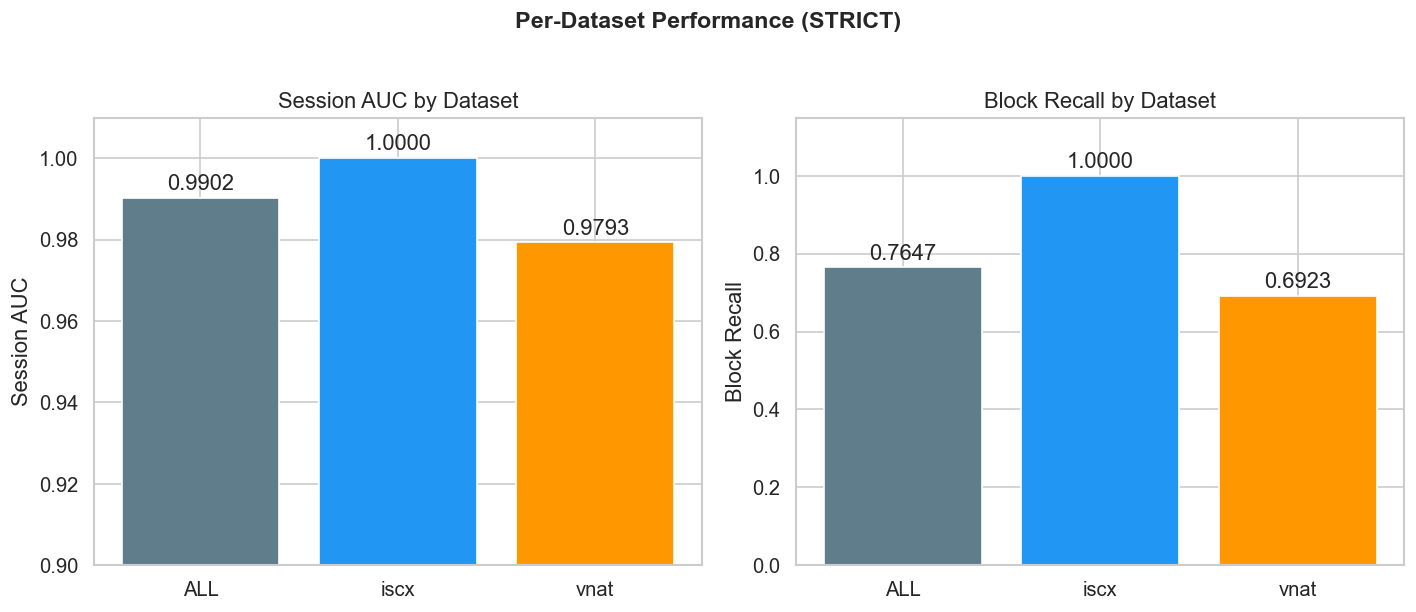

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ds_names = per_ds_df['Dataset'].tolist()
ds_colors = ['#607D8B' if d=='ALL' else '#2196F3' if d=='iscx' else '#FF9800' for d in ds_names]

ax = axes[0]
ax.bar(ds_names, per_ds_df['Session AUC'], color=ds_colors, edgecolor='white')
ax.set_ylabel('Session AUC'); ax.set_title('Session AUC by Dataset'); ax.set_ylim(0.9, 1.01)
for i, v in enumerate(per_ds_df['Session AUC']): ax.text(i, v+0.002, f'{v:.4f}', ha='center')

ax = axes[1]
ax.bar(ds_names, per_ds_df['Block Recall'], color=ds_colors, edgecolor='white')
ax.set_ylabel('Block Recall'); ax.set_title('Block Recall by Dataset'); ax.set_ylim(0, 1.15)
for i, v in enumerate(per_ds_df['Block Recall']): ax.text(i, v+0.02, f'{v:.4f}', ha='center')

plt.suptitle('Per-Dataset Performance (STRICT)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 10. Session-Level ROC & PR Curves

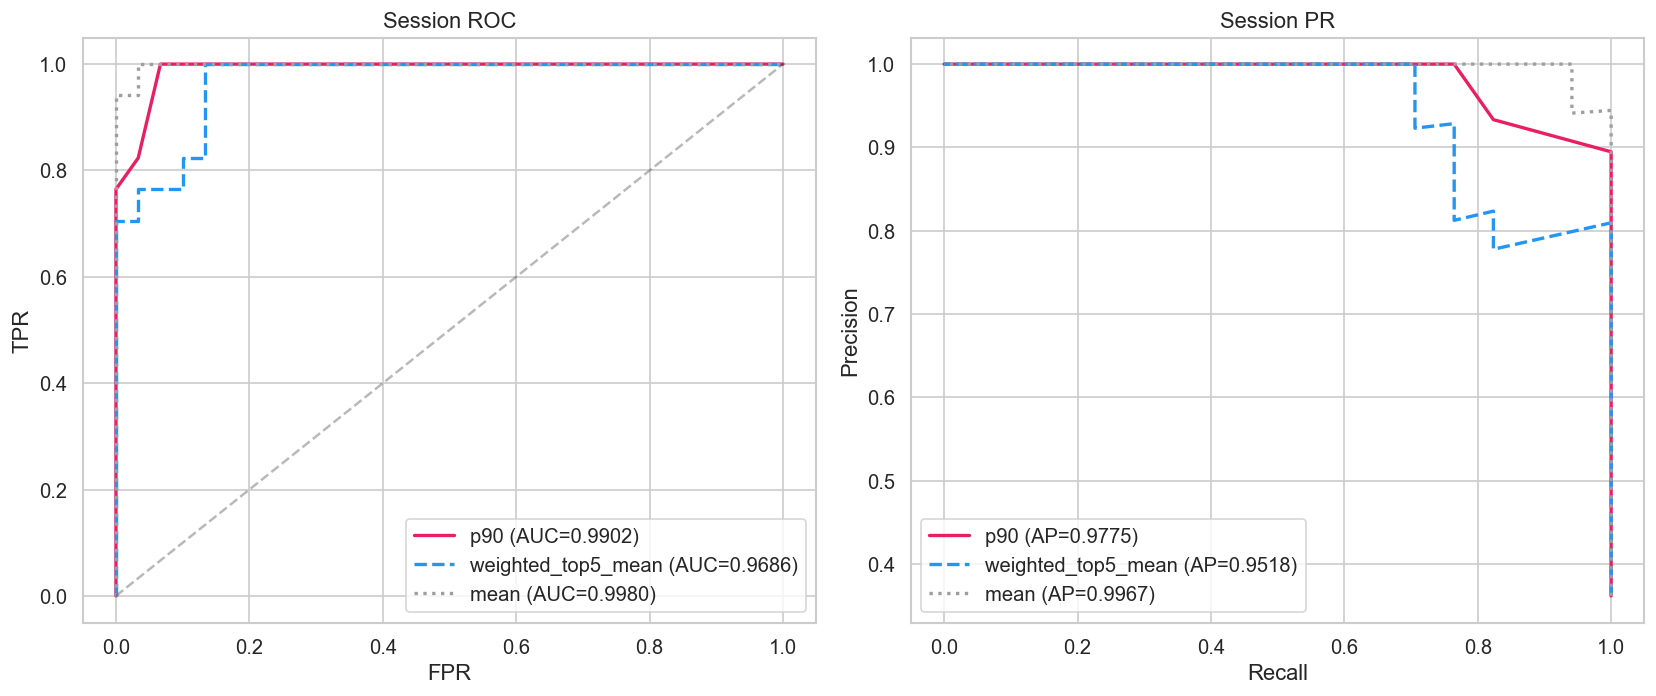

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
session_labels = test_df.groupby('capture_id')['label'].max()
session_curves = [
    ('p90', p90_agg, '#E91E63', '-'),
    ('weighted_top5_mean', weighted_top5, '#2196F3', '--'),
    ('mean', mean_agg, '#9E9E9E', ':'),
]

for ax_idx, (ax, metric_fn, title) in enumerate([
    (axes[0], roc_curve, 'Session ROC'), (axes[1], precision_recall_curve, 'Session PR')
]):
    for agg_name, agg_fn, color, ls in session_curves:
        ss = test_df.groupby('capture_id')['prob_iso'].apply(lambda x: agg_fn(x.values))
        common = session_labels.index.intersection(ss.index)
        y = session_labels.loc[common].values; s = ss.loc[common].values
        if ax_idx == 0:
            fpr, tpr, _ = roc_curve(y, s)
            ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
                    label=f'{agg_name} (AUC={roc_auc_score(y,s):.4f})')
        else:
            prec, rec, _ = precision_recall_curve(y, s)
            ax.plot(rec, prec, color=color, linestyle=ls, linewidth=2,
                    label=f'{agg_name} (AP={average_precision_score(y,s):.4f})')
    ax.set_title(title); ax.legend()
    if ax_idx == 0:
        ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    else:
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
plt.tight_layout(); plt.show()

## 11. Model Family Agreement

Family Agreement (# families voting VPN):

votes     0   1   2    3
label                   
0      1507  22  25   39
1        40   2   7  202


Unanimous agreement: 97.0%, Disagreement: 3.0%

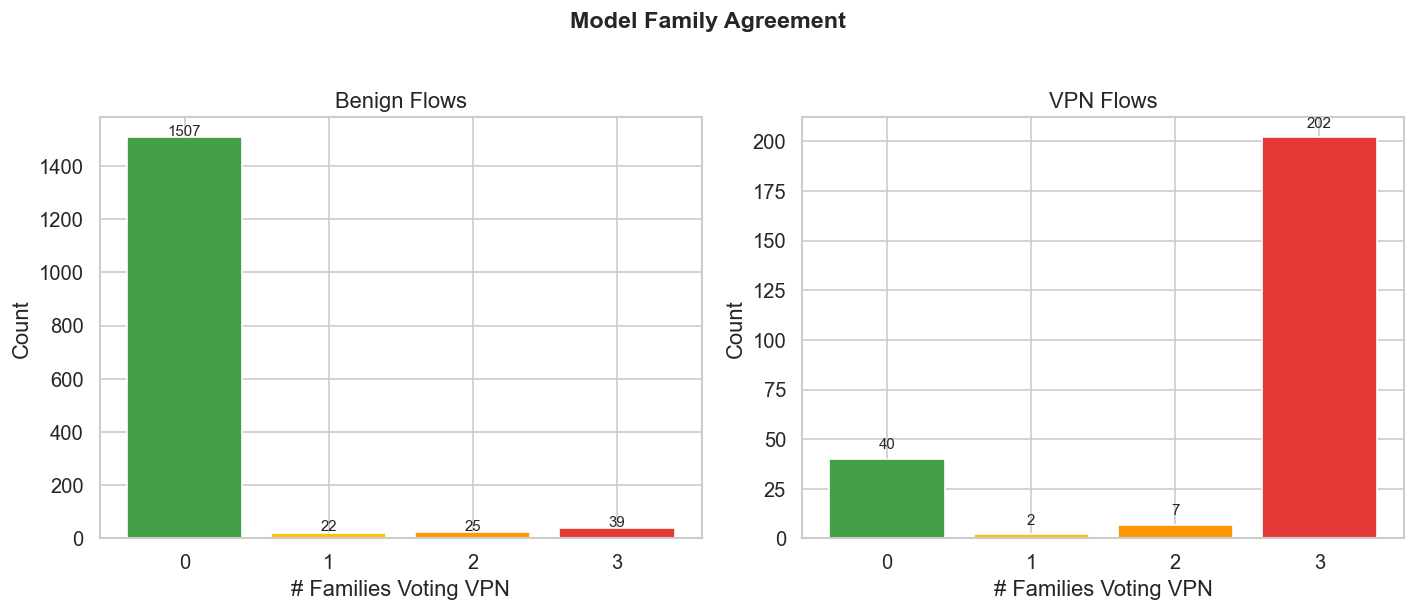

In [18]:
tp = test_df[['flow_id','label','p_xgb_raw','p_lgbm_raw','p_cat_raw']].copy()
tp['votes'] = (tp['p_xgb_raw']>0.5).astype(int) + (tp['p_lgbm_raw']>0.5).astype(int) + (tp['p_cat_raw']>0.5).astype(int)

print('Family Agreement (# families voting VPN):')
print(tp.groupby(['label','votes']).size().unstack(fill_value=0))
unanimous = tp['votes'].isin([0, 3]).mean()
print(f'\nUnanimous agreement: {unanimous:.1%}, Disagreement: {1-unanimous:.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
vote_colors = ['#43A047', '#FFC107', '#FF9800', '#E53935']
for ax, lv, ln in [(axes[0],0,'Benign'),(axes[1],1,'VPN')]:
    vc = tp[tp['label']==lv]['votes'].value_counts().sort_index()
    ax.bar(vc.index, vc.values, color=[vote_colors[i] for i in vc.index], edgecolor='white')
    ax.set_xlabel('# Families Voting VPN'); ax.set_ylabel('Count'); ax.set_title(f'{ln} Flows')
    ax.set_xticks([0,1,2,3])
    for i, v in zip(vc.index, vc.values): ax.text(i, v+5, str(v), ha='center', fontsize=9)
plt.suptitle('Model Family Agreement', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 12. Family Probability Correlations

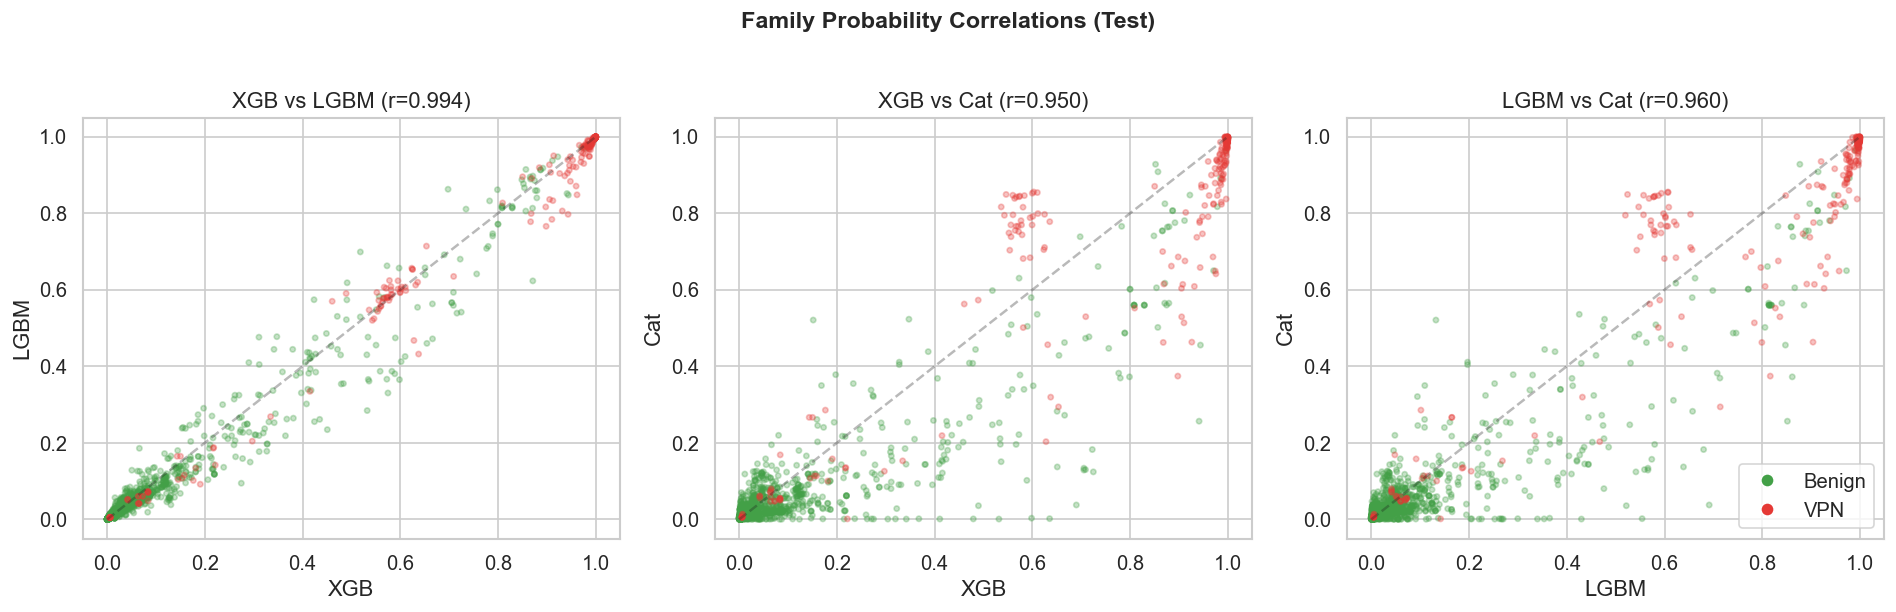

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [('p_xgb_raw','p_lgbm_raw','XGB','LGBM'),('p_xgb_raw','p_cat_raw','XGB','Cat'),('p_lgbm_raw','p_cat_raw','LGBM','Cat')]
for ax, (c1, c2, n1, n2) in zip(axes, pairs):
    colors = [COLORS['vpn'] if l==1 else COLORS['benign'] for l in test_df['label']]
    ax.scatter(test_df[c1], test_df[c2], c=colors, alpha=0.3, s=10)
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_xlabel(n1); ax.set_ylabel(n2)
    ax.set_title(f'{n1} vs {n2} (r={test_df[c1].corr(test_df[c2]):.3f})')
from matplotlib.lines import Line2D
axes[2].legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=COLORS['benign'],markersize=8,label='Benign'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=COLORS['vpn'],markersize=8,label='VPN'),
], loc='lower right')
plt.suptitle('Family Probability Correlations (Test)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 13. Confusion Matrices — STRICT Mode

2026-03-30 14:11:25 | INFO | firewall.blocker | Loading firewall pipeline (mode=strict)...


2026-03-30 14:11:25 | INFO | firewall.predictor | Loaded isotonic calibrator (raw sklearn IsotonicRegression)


2026-03-30 14:11:25 | INFO | firewall.predictor | Ensemble loaded: 9 models across 3 families, calibration=isotonic


2026-03-30 14:11:25 | INFO | firewall.blocker | Firewall pipeline loaded successfully.


2026-03-30 14:11:25 | INFO | firewall.blocker | Loading validation predictions from C:\Users\scoti\PycharmProjects\ai-vpn-firewall\artifacts\balanced_bagging_firewall_tuned_ensemble\predictions.csv


2026-03-30 14:11:26 | INFO | firewall.policy | Thresholds calibrated (strict): block=0.958769, flag=0.671138


2026-03-30 14:11:26 | INFO | firewall.blocker | Thresholds calibrated: block=0.958769, flag=0.671138


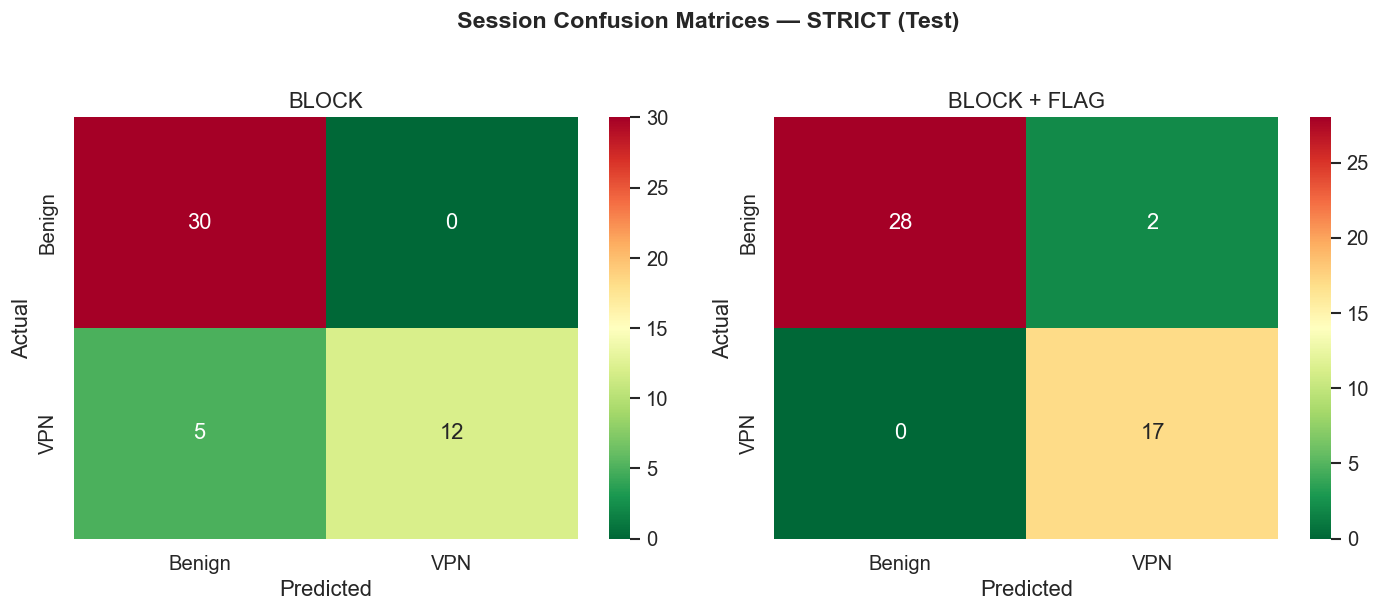

In [20]:
blocker = FirewallBlocker(mode=DeploymentMode.STRICT)
blocker.load(); blocker.calibrate_from_validation()

preds_eval = test_df.rename(columns={'prob_iso': 'prob_cal'})
decisions = blocker._policy.predict_sessions_batch(preds_eval)
session_labels = test_df.groupby('capture_id')['label'].max().to_dict()

y_true, y_block, y_flag = [], [], []
for d in decisions:
    lbl = session_labels.get(d.capture_id, -1)
    if lbl < 0: continue
    y_true.append(lbl)
    y_block.append(1 if d.decision.value == 'BLOCK' else 0)
    y_flag.append(1 if d.decision.value in ('BLOCK','FLAG') else 0)

y_true=np.array(y_true); y_block=np.array(y_block); y_flag=np.array(y_flag)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, title in [(axes[0],y_block,'BLOCK'),(axes[1],y_flag,'BLOCK + FLAG')]:
    cm = confusion_matrix(y_true, yp, labels=[0,1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r', ax=ax,
                xticklabels=['Benign','VPN'], yticklabels=['Benign','VPN'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual'); ax.set_title(title)
plt.suptitle('Session Confusion Matrices — STRICT (Test)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 14. Recall vs FPR Budget Sweep

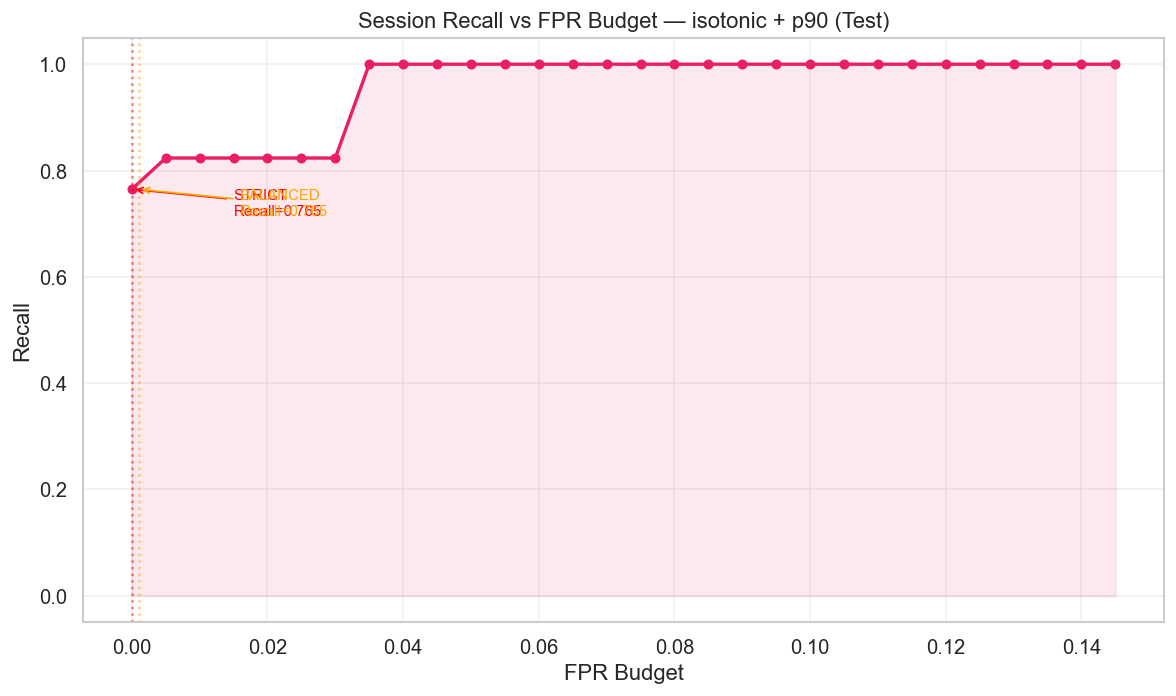

Key operating points:

 FPR Budget  Recall
      0.000  0.7647
      0.005  0.8235
      0.010  0.8235
      0.050  1.0000
      0.100  1.0000

In [21]:
sl = test_df.groupby('capture_id')['label'].max()
ss = test_df.groupby('capture_id')['prob_iso'].apply(lambda x: p90_agg(x.values))
common = sl.index.intersection(ss.index)
y_sess = sl.loc[common].values; s_sess = ss.loc[common].values
benign_sess = s_sess[y_sess==0]; vpn_sess = s_sess[y_sess==1]

fpr_budgets = np.arange(0.0, 0.15, 0.005)
sweep = []
for fpr_t in fpr_budgets:
    thr = np.max(benign_sess) if fpr_t == 0.0 else np.quantile(benign_sess, 1.0-fpr_t)
    sweep.append({'FPR Budget': fpr_t, 'Recall': float(np.mean(vpn_sess > thr))})
sweep_df = pd.DataFrame(sweep)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(sweep_df['FPR Budget'], sweep_df['Recall'], 'o-', color='#E91E63', linewidth=2, markersize=5)
ax.fill_between(sweep_df['FPR Budget'], sweep_df['Recall'], alpha=0.1, color='#E91E63')
for fpr_mark, label, color in [(0.0,'STRICT','red'),(0.001,'BALANCED','orange')]:
    row = sweep_df.iloc[(sweep_df['FPR Budget']-fpr_mark).abs().argmin()]
    ax.axvline(fpr_mark, color=color, linestyle=':', alpha=0.5)
    ax.annotate(f'{label}\nRecall={row["Recall"]:.3f}', xy=(fpr_mark, row['Recall']),
                xytext=(fpr_mark+0.015, row['Recall']-0.05),
                arrowprops=dict(arrowstyle='->', color=color), fontsize=9, color=color)
ax.set_xlabel('FPR Budget'); ax.set_ylabel('Recall')
ax.set_title('Session Recall vs FPR Budget — isotonic + p90 (Test)')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print('Key operating points:')
print(sweep_df[sweep_df['FPR Budget'].isin([0.0, 0.005, 0.01, 0.05, 0.10])].round(4).to_string(index=False))

## 15. Final Deployment Summary

In [22]:
sm = mode_metrics['strict']
print('='*72)
print('  FINAL DEPLOYMENT SUMMARY — VPN Detection Firewall')
print('='*72)
print()
print('  Ensemble: 3xXGBoost + 3xLightGBM + 3xCatBoost (balanced bagging)')
print('  Calibration: Isotonic regression')
print('  Session aggregation: p90 (90th percentile)')
print('  Threshold: max(benign session score) on validation set')
print('  Features: 7 compact flow-level statistics')
print()
print('  STRICT MODE (Production Default)')
print('  ' + '-'*50)
print(f'  Block Recall:     {sm["block_recall"]:.4f}')
print(f'  Block FPR:        {sm["block_fpr"]:.4f}')
print(f'  Block Precision:  {sm["block_precision"]:.4f}')
print(f'  Flagged Recall:   {sm["flagged_recall"]:.4f}')
print(f'  Flagged FPR:      {sm["flagged_fpr"]:.4f}')
print(f'  Session AUC:      {sm["session_roc_auc"]:.4f}')
print(f'  Session PR-AUC:   {sm["session_pr_auc"]:.4f}')
print(f'  Block Threshold:  {sm["block_threshold"]:.6f}')
print(f'  Sessions:         {sm["n_sessions_evaluated"]} ({sm["n_positive"]} VPN, {sm["n_negative"]} benign)')
print()
print('  KEY TAKEAWAYS')
print('  ' + '-'*50)
print('  [check] Block FPR = 0 guaranteed (zero false blocks)')
print(f'  [check] {sm["block_recall"]:.1%} of VPN sessions blocked with certainty')
print(f'  [check] {sm["flagged_recall"]:.1%} of VPN sessions detected (blocked + flagged)')
print('  [check] Isotonic calibration improves probability quality')
print('  [check] p90 aggregation most conservative session strategy')
print('  [warn]  VNAT has only 13 VPN sessions - metrics are high-variance')
print('  [warn]  direction_balance features enable domain fingerprinting')
print('='*72)

  FINAL DEPLOYMENT SUMMARY — VPN Detection Firewall

  Ensemble: 3xXGBoost + 3xLightGBM + 3xCatBoost (balanced bagging)

  Calibration: Isotonic regression

  Session aggregation: p90 (90th percentile)

  Threshold: max(benign session score) on validation set

...

  [check] 100.0% of VPN sessions detected (blocked + flagged)

  [check] Isotonic calibration improves probability quality

  [check] p90 aggregation most conservative session strategy

  [warn]  VNAT has only 13 VPN sessions - metrics are high-variance

  [warn]  direction_balance features enable domain fingerprinting